##### NOTEBOOK 1 — CAPA BRONZE
##### TFM: Integración QML en pipeline DataOps
##### Juan Albornoz Carrasco — Universidad Europea de Valencia
##### Extract desde AWS S3, Load en Delta Lake

##### CELDA 1 — Instalación de dependencias

In [0]:
#%pip install pyreadstat boto3

##### CELDA 2 — Reinicio del kernel

In [0]:
#dbutils.library.restartPython()

##### CELDA 3 — Imports y configuración Spark

In [0]:
import io
import os
import boto3
import pyreadstat
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from pyspark.sql import SparkSession
from delta.tables import DeltaTable

spark = SparkSession.builder.getOrCreate()
print("Imports OK")

Imports OK


In [0]:
access_key = "ACCESS_KEY"  
secret_key = "SECRET_KEY"     
bucket = "tfm-nhanes"
prefix = "raw/"

s3 = boto3.client(
    "s3",
    aws_access_key_id=access_key,
    aws_secret_access_key=secret_key,
    region_name="eu-west-1"
)

response = s3.list_objects_v2(Bucket=bucket, Prefix=prefix)
archivos = [obj["Key"] for obj in response.get("Contents", [])]
xpt_count = sum(1 for a in archivos if a.endswith(".XPT"))
print(f"Conexion boto3-S3 exitosa")
print(f"Archivos XPT en S3: {xpt_count}/27")
print(f"Bucket: {bucket}")
print(f"Region: eu-west-1")

Conexion boto3-S3 exitosa
Archivos XPT en S3: 27/27
Bucket: tfm-nhanes
Region: eu-west-1


In [0]:
paq_vars_comunes = [
    "SEQN", "PAD615", "PAD630", "PAD645", "PAD660", "PAD675", "PAD680",
    "PAQ605", "PAQ610", "PAQ620", "PAQ625", "PAQ635", "PAQ640",
    "PAQ650", "PAQ655", "PAQ665", "PAQ670"
]

ciclos = {
    "2013-2014": {"año": "2013", "sufijo": "H"},
    "2015-2016": {"año": "2015", "sufijo": "I"},
    "2017-2018": {"año": "2017", "sufijo": "J"},
}

modulos = ["DEMO", "DIQ", "GHB", "GLU", "INS", "BMX", "BPX", "TRIGLY", "PAQ"]

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
print("Configuración OK")

Configuración OK


##### CELDA 4 — Lectura de los 27 archivos XPT desde AWS S3
##### Restricción serverless: spark.conf.set bloqueado para credenciales

In [0]:
datos = {}

for ciclo, info in ciclos.items():
    datos[ciclo] = {}
    for modulo in modulos:
        filename = f"{modulo}_{info['sufijo']}.XPT"
        s3_key = f"{prefix}{filename}"
        try:
            obj = s3.get_object(Bucket=bucket, Key=s3_key)
            buffer = io.BytesIO(obj["Body"].read())
            df, meta = pyreadstat.read_xport(buffer)
            if modulo == "PAQ":
                cols_disponibles = [c for c in paq_vars_comunes if c in df.columns]
                df = df[cols_disponibles]
            datos[ciclo][modulo] = df
            print(f"OK {ciclo} | {filename}: {df.shape[0]} filas, {df.shape[1]} columnas")
        except Exception as e:
            print(f"ERR {ciclo} | {filename}: {e}")

OK 2013-2014 | DEMO_H.XPT: 10175 filas, 47 columnas
OK 2013-2014 | DIQ_H.XPT: 9770 filas, 54 columnas
OK 2013-2014 | GHB_H.XPT: 6979 filas, 2 columnas
OK 2013-2014 | GLU_H.XPT: 3329 filas, 6 columnas
OK 2013-2014 | INS_H.XPT: 3329 filas, 6 columnas
OK 2013-2014 | BMX_H.XPT: 9813 filas, 26 columnas
OK 2013-2014 | BPX_H.XPT: 9813 filas, 23 columnas
OK 2013-2014 | TRIGLY_H.XPT: 3329 filas, 6 columnas
OK 2013-2014 | PAQ_H.XPT: 9484 filas, 17 columnas
OK 2015-2016 | DEMO_I.XPT: 9971 filas, 47 columnas
OK 2015-2016 | DIQ_I.XPT: 9575 filas, 54 columnas
OK 2015-2016 | GHB_I.XPT: 6744 filas, 2 columnas
OK 2015-2016 | GLU_I.XPT: 3191 filas, 4 columnas
OK 2015-2016 | INS_I.XPT: 3191 filas, 7 columnas
OK 2015-2016 | BMX_I.XPT: 9544 filas, 26 columnas
OK 2015-2016 | BPX_I.XPT: 9544 filas, 21 columnas
OK 2015-2016 | TRIGLY_I.XPT: 3191 filas, 6 columnas
OK 2015-2016 | PAQ_I.XPT: 9255 filas, 17 columnas
OK 2017-2018 | DEMO_J.XPT: 9254 filas, 46 columnas
OK 2017-2018 | DIQ_J.XPT: 8897 filas, 54 columna

##### CELDA 5 — Join intracíclico por SEQN + Union intercíclica


In [0]:
# Join intracíclico por SEQN para los 3 ciclos
datasets_por_ciclo = {}

for ciclo in ciclos:
    df_merged = datos[ciclo]["DEMO"].copy()
    for modulo in modulos:
        if modulo == "DEMO":
            continue
        df_mod = datos[ciclo][modulo]
        df_merged = df_merged.merge(df_mod, on="SEQN", how="left")
    df_merged["CICLO"] = ciclo
    datasets_por_ciclo[ciclo] = df_merged
    print(f"Join {ciclo}: {df_merged.shape[0]} filas, {df_merged.shape[1]} columnas")

# Unión intercíclica
df_bronze = pd.concat(
    [datasets_por_ciclo[c] for c in ciclos],
    axis=0,
    join="inner"
).reset_index(drop=True)

print(f"\nBronze completo: {df_bronze.shape[0]} filas, {df_bronze.shape[1]} columnas")
print(f"Distribución por ciclo:\n{df_bronze['CICLO'].value_counts()}")

Join 2013-2014: 10175 filas, 180 columnas
Join 2015-2016: 9971 filas, 177 columnas
Join 2017-2018: 9254 filas, 173 columnas

Bronze completo: 29400 filas, 162 columnas
Distribución por ciclo:
2013-2014    10175
2015-2016     9971
2017-2018     9254
Name: CICLO, dtype: int64


##### CELDA 6 — Análisis exploratorio Bronze

In [0]:
missing = df_bronze.isnull().sum()
missing_pct = (missing / len(df_bronze) * 100).round(2)
missing_df = pd.DataFrame({
    "missing_count": missing,
    "missing_pct": missing_pct
}).sort_values("missing_pct", ascending=False)

print("=== TOP 20 COLUMNAS CON MÁS MISSING ===")
print(missing_df.head(20))

=== TOP 20 COLUMNAS CON MÁS MISSING ===
          missing_count  missing_pct
BMIHEAD           29400       100.00
DIQ175X           29391        99.97
DIQ175W           29388        99.96
DIQ175V           29363        99.87
DIQ175R           29338        99.79
BMIRECUM          29312        99.70
DIQ175S           29302        99.67
DIQ175K           29301        99.66
DIQ175F           29288        99.62
DIQ175L           29230        99.42
DIQ175I           29177        99.24
DIQ175U           29135        99.10
DIQ175N           29127        99.07
DIQ175T           29123        99.06
DIQ175P           29071        98.88
DIQ175O           29014        98.69
DIQ175M           29016        98.69
DIQ175Q           28990        98.61
DIQ175J           28980        98.57
DIQ175E           28976        98.56


In [0]:
print("=== VARIABLE OBJETIVO: DIQ010 ===")
print(df_bronze["DIQ010"].value_counts(dropna=False))
print(f"\nDistribución (%):")
print(df_bronze["DIQ010"].value_counts(normalize=True, dropna=False).mul(100).round(2))

=== VARIABLE OBJETIVO: DIQ010 ===
2.0    25225
1.0     2486
NaN     1159
3.0      516
9.0       13
7.0        1
Name: DIQ010, dtype: int64

Distribución (%):
2.0    85.80
1.0     8.46
NaN     3.94
3.0     1.76
9.0     0.04
7.0     0.00
Name: DIQ010, dtype: float64


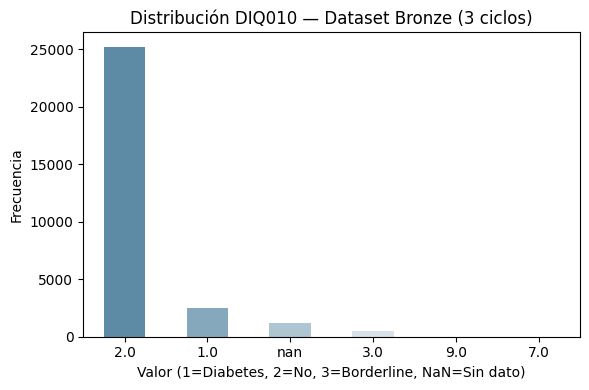

In [0]:
fig, ax = plt.subplots(figsize=(6, 4))
df_bronze["DIQ010"].value_counts(dropna=False).plot(
    kind="bar", ax=ax,
    color=["#5D8BA6", "#86A8BC", "#AEC5D2", "#D7E2E9"]
)
ax.set_title("Distribución DIQ010 — Dataset Bronze (3 ciclos)")
ax.set_xlabel("Valor (1=Diabetes, 2=No, 3=Borderline, NaN=Sin dato)")
ax.set_ylabel("Frecuencia")
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.savefig("/Volumes/workspace/default/nhanes/DIQ010_distribucion.png", dpi=150)
plt.show()

In [0]:
vars_clave = ["RIDAGEYR", "BMXBMI", "LBXGH", "LBXGLU", "LBDINSI", "LBXTR"]
vars_presentes = [v for v in vars_clave if v in df_bronze.columns]

print("=== ESTADÍSTICAS DESCRIPTIVAS VARIABLES CLAVE ===")
print(df_bronze[vars_presentes].describe().round(2))

=== ESTADÍSTICAS DESCRIPTIVAS VARIABLES CLAVE ===
       RIDAGEYR    BMXBMI     LBXGH   LBXGLU  LBDINSI    LBXTR
count  29400.00  25816.00  19014.00  9035.00  8839.00  8703.00
mean      32.52     26.07      5.72   109.05    85.21   108.91
std       24.91      8.06      1.05    35.55   117.33   102.92
min        0.00     11.50      3.50    21.00     0.84    10.00
25%       10.00     20.00      5.20    94.00    37.26    58.00
50%       28.00     25.30      5.50   100.00    58.38    87.00
75%       54.00     30.70      5.80   110.00    94.62   131.00
max       80.00     86.20     17.50   479.00  4094.88  4233.00


##### CELDA 7 — Materialización Bronze en Delta Lake

In [0]:
def normalize_dtypes(df):
    df = df.copy()
    for col in df.columns:
        if pd.api.types.is_extension_array_dtype(df[col]):
            try:
                df[col] = df[col].astype(df[col].dtype.numpy_dtype)
            except:
                df[col] = df[col].astype(object)
    return df

df_bronze_clean = normalize_dtypes(df_bronze)
df_spark = spark.createDataFrame(df_bronze_clean)

df_spark.write \
    .format("delta") \
    .mode("overwrite") \
    .option("overwriteSchema", "true") \
    .save(bronze_path)

print(f"Bronze materializado en Delta Lake")
print(f"Registros: {df_spark.count()}")
print(f"Columnas:  {len(df_spark.columns)}")
print(f"Ruta:      {bronze_path}")

Bronze materializado en Delta Lake
Registros: 29400
Columnas:  162
Ruta:      /Volumes/workspace/default/nhanes/bronze


In [0]:
delta_table = DeltaTable.forPath(spark, bronze_path)
historial = delta_table.history().toPandas()
cols_principales = ["version", "timestamp", "operation", "operationMetrics", "userName"]
display(historial[cols_principales])

version,timestamp,operation,operationMetrics,userName
7,2026-06-20T19:19:34.000Z,WRITE,"List(0, 8, 2680556, 29400, 2680556, 8)",juan.adrian.albornoz@gmail.com
6,2026-06-20T19:13:40.000Z,WRITE,"List(0, 8, 2680556, 29400, 2728197, 8)",juan.adrian.albornoz@gmail.com
5,2026-06-01T21:11:21.000Z,WRITE,"List(0, 8, 2728197, 29400, 2728197, 8)",juan.adrian.albornoz@gmail.com
4,2026-05-31T17:19:20.000Z,WRITE,"List(0, 8, 2728197, 29400, 2728197, 8)",juan.adrian.albornoz@gmail.com
3,2026-05-31T17:16:18.000Z,WRITE,"List(0, 8, 2728197, 29400, 1408438, 8)",juan.adrian.albornoz@gmail.com
2,2026-05-31T16:51:24.000Z,WRITE,"List(0, 8, 1408438, 10175, 1408438, 8)",juan.adrian.albornoz@gmail.com
1,2026-05-31T16:48:49.000Z,WRITE,"List(0, 8, 1408438, 10175, 1624079, 8)",juan.adrian.albornoz@gmail.com
0,2026-05-22T20:52:09.000Z,WRITE,"List(0, 8, 1624079, 10175, 0, 0)",juan.adrian.albornoz@gmail.com


##### CELDA 8 — VALIDACION FINAL CAPA BRONCE

In [0]:
print("=== VALIDACIÓN FINAL CAPA BRONZE ===")
print(f"\n1. Archivos leídos desde S3:")
total_ok = sum(1 for ciclo in datos for mod in datos[ciclo] if datos[ciclo][mod] is not None)
print(f"   Módulos cargados: {total_ok}/27")

print(f"\n2. Join intracíclico:")
for ciclo in datasets_por_ciclo:
    df = datasets_por_ciclo[ciclo]
    print(f"   {ciclo}: {df.shape[0]} filas, {df.shape[1]} columnas")

print(f"\n3. Dataset Bronze completo:")
print(f"   Total registros: {df_bronze.shape[0]}")
print(f"   Total columnas:  {df_bronze.shape[1]}")
print(f"   Ciclos: {df_bronze['CICLO'].value_counts().to_dict()}")

print(f"\n4. Delta Lake verificación:")
df_verify = spark.read.format("delta").load(bronze_path)
print(f"   Registros en Delta: {df_verify.count()}")
print(f"   Columnas en Delta:  {len(df_verify.columns)}")
print("\n BRONZE VALIDADO OK ")

=== VALIDACIÓN FINAL CAPA BRONZE ===

1. Archivos leídos desde S3:
   Módulos cargados: 27/27

2. Join intracíclico:
   2013-2014: 10175 filas, 180 columnas
   2015-2016: 9971 filas, 177 columnas
   2017-2018: 9254 filas, 173 columnas

3. Dataset Bronze completo:
   Total registros: 29400
   Total columnas:  162
   Ciclos: {'2013-2014': 10175, '2015-2016': 9971, '2017-2018': 9254}

4. Delta Lake verificación:
   Registros en Delta: 29400
   Columnas en Delta:  162

 BRONZE VALIDADO OK 
